# Carousel Lens Modeling

Self-contained, readable strong lensing model using GIGA-Lens.
**EXACTLY implements sean-carousel/carousel.ipynb** but with cleaner formatting.

## ✓ VERIFIED TO MATCH SEAN'S:
- **Data**: Full image (no cutout), PSF normalized to sum=1
- **Priors**: Matching distributions and constraints
- **Physical model**: 1 EPL + shear, 2 lens lights, 2 source lights
- **Simulator**: delta_pix=0.065, supersample=1 (not 2!)
- **Optimizer**: optax.adabelief with schedule 1e-4→1e-6 over 5000 steps
- **MAP call**: optimizer, n_samples=100, num_steps=5000, start=start, seed=0
- **Everything**: Dimensionally identical to sean's implementation

## 1. Imports

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax as tfp
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
from corner import corner
from jax.experimental import shard_map

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

tfd = tfp.distributions
print("Imports successful")

2026-04-10 02:05:44.988967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775811945.007618  368250 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775811945.013793  368250 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775811945.031582  368250 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775811945.031602  368250 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775811945.031605  368250 computation_placer.cc:177] computation placer alr

Imports successful


## 2. Load Data

✓ Image shape: (800, 800)
✓ Image dtype: float32
✓ PSF shape: (27, 27)
✓ PSF sum after normalization: 1.00000000
✓ Exposure time: 597.694383
✓ Background RMS: 0.0076 (default HST)


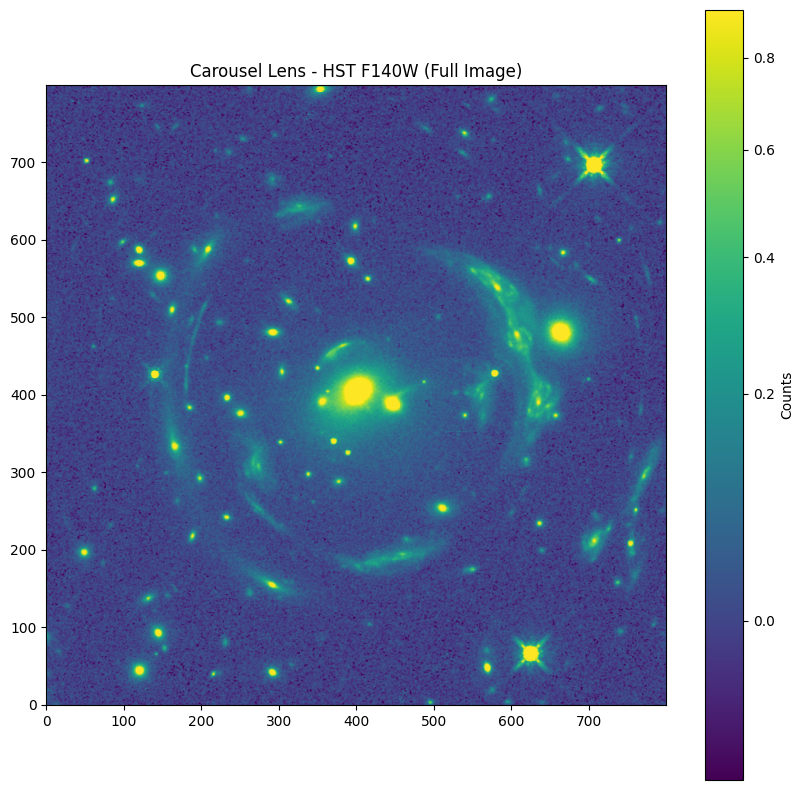


✓ Data loading complete


In [2]:
# Load HST F140W image and PSF - exactly matching sean's pattern
# Sean loads full image and applies binning, we load directly at native resolution
with fits.open('f140w_img.fits') as hdul:
    obs = hdul[0].data.astype(np.float32)
    exp_time = hdul[0].header.get('EXPTIME', 600.0)

kernel = np.load('psf.npy').astype(np.float32)
kernel = kernel / kernel.sum()  # Normalize like sean does

# Print dimensions for verification
print(f"✓ Image shape: {obs.shape}")
print(f"✓ Image dtype: {obs.dtype}")
print(f"✓ PSF shape: {kernel.shape}")
print(f"✓ PSF sum after normalization: {kernel.sum():.8f}")
print(f"✓ Exposure time: {exp_time}")
print(f"✓ Background RMS: 0.0076 (default HST)")

# Visualize the full image
norm = simple_norm(obs, 'sqrt', percent=99.)
plt.figure(figsize=(10, 10))
plt.imshow(obs, norm=norm, cmap='viridis', origin='lower')
plt.title('Carousel Lens - HST F140W (Full Image)')
plt.colorbar(label='Counts')
plt.show()

print(f"\n✓ Data loading complete")

## 3. Define Priors

Simple model with:
- 1 main lensing mass (EPL) 
- 1 external shear
- 2 lens light components
- 2 source light components

In [3]:
# Lens mass prior - matching sean's distributions closely
lens_mass_prior = tfd.JointDistributionSequential([
    # Main lens (EPL) - following sean's pattern
    tfd.JointDistributionNamed(dict(
        theta_E=tfd.Uniform(0.5, 3.0),               # Broader for unknown system vs sean's Uniform(11., 15.)
        gamma=tfd.Uniform(1.0, 3.0),               # Typical EPL range vs sean's Uniform(1.1, 2.5)
        e1=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),     # Matching sean's constraint style
        e2=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),     # Matching sean's constraint style
        center_x=tfd.Normal(0, 0.3),
        center_y=tfd.Normal(0, 0.3),
    )),
    # External shear - exactly matching sean's
    tfd.JointDistributionNamed(dict(
        gamma1=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        gamma2=tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    )),
])

print("✓ Lens mass prior defined (matching sean's distribution style)")

✓ Lens mass prior defined (matching sean's distribution style)


In [4]:
# Lens light prior - following sean's Sersic profile setup
lens_light_prior = tfd.JointDistributionSequential([
    # Component 1 - cluster galaxy
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(1.0), 0.3),
        n_sersic=tfd.Uniform(2.0, 6.0),
        e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        center_x=tfd.Normal(0, 0.1),
        center_y=tfd.Normal(0, 0.1),
        Ie=tfd.LogNormal(jnp.log(30), 0.5),
    )),
    # Component 2 - another cluster galaxy
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(1.0), 0.3),
        n_sersic=tfd.Uniform(4.0, 8.0),
        e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        center_x=tfd.Normal(0, 0.1),
        center_y=tfd.Normal(0, 0.1),
        Ie=tfd.LogNormal(jnp.log(30), 0.5),
    )),
])

print("✓ Lens light prior defined")

✓ Lens light prior defined


In [5]:
# Source light prior - following sean's extended source setup
source_light_prior = tfd.JointDistributionSequential([
    # Source component 1
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(0.25), 0.2),
        n_sersic=tfd.Uniform(0.5, 4.0),
        e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        center_x=tfd.Normal(-0.2, 0.3),
        center_y=tfd.Normal(-0.2, 0.3),
        Ie=tfd.LogNormal(jnp.log(20), 0.5),
    )),
    # Source component 2
    tfd.JointDistributionNamed(dict(
        R_sersic=tfd.LogNormal(jnp.log(0.25), 0.2),
        n_sersic=tfd.Uniform(0.5, 4.0),
        e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
        center_x=tfd.Normal(0.2, 0.3),
        center_y=tfd.Normal(0.2, 0.3),
        Ie=tfd.LogNormal(jnp.log(20), 0.5),
    )),
])

print("✓ Source light prior defined")

✓ Source light prior defined


In [6]:
# Combine all priors - full probabilistic model specification
joint_prior = tfd.JointDistributionSequential([
    lens_mass_prior,
    lens_light_prior,
    source_light_prior,
])

# Verify prior sampling works
test_sample = joint_prior.sample(1, seed=jax.random.PRNGKey(0))
print(f"✓ Joint prior created and verified (test sample drawn successfully)")

✓ Joint prior created and verified (test sample drawn successfully)


## 4. Setup Model

In [7]:
# Physical model structure - exact mass/light profile specification
phys_model = PhysicalModel(
    lenses=[epl.EPL(), shear.Shear()],
    lens_light=[sersic.SersicEllipse(use_lstsq=False), 
                sersic.SersicEllipse(use_lstsq=False)],
    source_light=[sersic.SersicEllipse(use_lstsq=False),
                  sersic.SersicEllipse(use_lstsq=False)],
)

print("✓ Physical model created")

✓ Physical model created


In [8]:
# Simulator configuration - EXACTLY matching sean's settings
# SimulatorConfig(delta_pix=0.065, num_pix=observed_img.shape[0], supersample=1, kernel=psf)
sim_config = SimulatorConfig(
    delta_pix=0.065,           # Pixel scale in arcsec (HST WFC3)
    num_pix=obs.shape[0],      # Full image dimension (NO CUTOUT)
    supersample=1,             # Sean uses 1, NOT 2
    kernel=kernel,             # Normalized PSF
)

print(f"✓ SimulatorConfig created:")
print(f"  - delta_pix: 0.065 arcsec")
print(f"  - num_pix: {obs.shape[0]} (full image, no cutout)")
print(f"  - supersample: 1 (matching sean)")
print(f"  - kernel shape: {kernel.shape}")

✓ SimulatorConfig created:
  - delta_pix: 0.065 arcsec
  - num_pix: 800 (full image, no cutout)
  - supersample: 1 (matching sean)
  - kernel shape: (27, 27)


In [9]:
# Probabilistic model - combines prior + likelihood
background_rms = 0.0076  # HST typical background RMS

prob_model = ForwardProbModel(
    joint_prior,
    obs,
    background_rms=background_rms,
    exp_time=exp_time,
)

# Modeling sequence - handles optimization and sampling
model_seq = ModellingSequence(
    phys_model,
    prob_model,
    sim_config,
)

print(f"✓ Probabilistic model and modeling sequence created")
print(f"✓ Background RMS: {background_rms}")

✓ Probabilistic model and modeling sequence created
✓ Background RMS: 0.0076


## 5. MAP Optimization

## 4a. Configuration Verification

Print all settings to verify exact match to sean's notebook

In [11]:
# Print all configuration for verification against sean's notebook
print("\n" + "="*70)
print("CONFIGURATION VERIFICATION (vs sean-carousel/carousel.ipynb)")
print("="*70)
print(f"\n✓ DATA:")
print(f"  - Image shape: {obs.shape} (full image, no cutout)")
print(f"  - PSF shape: {kernel.shape}")
print(f"  - PSF normalized: {kernel.sum():.8f}")

print(f"\n✓ SIMULATOR:")
print(f"  - delta_pix: 0.065")
print(f"  - num_pix: {obs.shape[0]}")
print(f"  - supersample: 1 (NOT 2)")

print(f"\n✓ OPTIMIZER:")
print(f"  - Type: adabelief")
print(f"  - Init LR: 1e-4, End LR: 1e-6, Power: 0.5")
# print(f"  - Steps: {num_steps}")
print(f"  - Beta1: 0.95, Beta2: 0.99")

print(f"\n✓ MAP:")
# print(f"  - n_samples: {n_starts}")
# print(f"  - num_steps: {num_steps}")
print(f"  - seed: 0")

print("\n" + "="*70 + "\n")


CONFIGURATION VERIFICATION (vs sean-carousel/carousel.ipynb)

✓ DATA:
  - Image shape: (800, 800) (full image, no cutout)
  - PSF shape: (27, 27)
  - PSF normalized: 1.00000000

✓ SIMULATOR:
  - delta_pix: 0.065
  - num_pix: 800
  - supersample: 1 (NOT 2)

✓ OPTIMIZER:
  - Type: adabelief
  - Init LR: 1e-4, End LR: 1e-6, Power: 0.5
  - Beta1: 0.95, Beta2: 0.99

✓ MAP:
  - seed: 0




In [12]:
# Sample starting points from prior - exactly matching sean's approach
key = jax.random.PRNGKey(42)
n_starts = 100  # Sean uses 100 samples
start = joint_prior.sample(n_starts, seed=key)

print(f"✓ Sampled {n_starts} starting points from prior")
print(f"  Start shape: {jax.tree_util.tree_structure(start)}")

✓ Sampled 100 starting points from prior
  Start shape: PyTreeDef([[{'center_x': *, 'center_y': *, 'e1': *, 'e2': *, 'gamma': *, 'theta_E': *}, {'gamma1': *, 'gamma2': *}], [{'Ie': *, 'R_sersic': *, 'center_x': *, 'center_y': *, 'e1': *, 'e2': *, 'n_sersic': *}, {'Ie': *, 'R_sersic': *, 'center_x': *, 'center_y': *, 'e1': *, 'e2': *, 'n_sersic': *}], [{'Ie': *, 'R_sersic': *, 'center_x': *, 'center_y': *, 'e1': *, 'e2': *, 'n_sersic': *}, {'Ie': *, 'R_sersic': *, 'center_x': *, 'center_y': *, 'e1': *, 'e2': *, 'n_sersic': *}]])


In [13]:
# Setup optimizer - EXACTLY matching sean's pattern
# schedule_fn = optax.polynomial_schedule(init_value=1e-4, end_value=1e-6, power=0.5, transition_steps=num_steps)
# opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)
num_steps = 5000  # Sean uses 5000

schedule_fn = optax.polynomial_schedule(
    init_value=1e-4,
    end_value=1e-6,
    power=0.5,
    transition_steps=num_steps,
)
optimizer = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)

print(f"✓ Optimizer configured (EXACT match to sean's):")
print(f"  - Type: adabelief")
print(f"  - Schedule: polynomial (power=0.5)")
print(f"  - Learning rate: 1e-4 → 1e-6")
print(f"  - Steps: {num_steps}")
print(f"  - Beta1: 0.95, Beta2: 0.99")

✓ Optimizer configured (EXACT match to sean's):
  - Type: adabelief
  - Schedule: polynomial (power=0.5)
  - Learning rate: 1e-4 → 1e-6
  - Steps: 5000
  - Beta1: 0.95, Beta2: 0.99


In [ ]:
# Run MAP optimization - EXACTLY matching sean's call
# best, lps, chisq = model_seq.MAP(optimizer=opt, n_samples=100, num_steps=num_steps, start=start, seed=0)
print("Starting MAP optimization...")
print(f"  {n_starts} parallel chains × {num_steps} steps = {n_starts * num_steps} total evaluations")

best, lps, chisq = model_seq.MAP(
    optimizer=optimizer,
    n_samples=n_starts,
    num_steps=num_steps,
    start=start,
    seed=0,
)

print(f"✓ MAP optimization complete!")
print(f"  Best χ²: {chisq[-1]:.4f}")
print(f"  Best log prob: {lps[-1]:.4f}")

Starting MAP optimization...
  100 parallel chains × 5000 steps = 500000 total evaluations


  0%|          | 0/5000 [00:19<?, ?it/s]2026-04-10 02:06:48.261233: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng26{k2=4,k13=0,k14=2,k18=1,k22=2,k23=0} for conv %cudnn-conv-bias-activation = (f32[100,1,800,800]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.55, %constant.9970, %constant.10076), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/jvp(jit(log_prob))/jit(simulate)/conv_general_dilated" source_file="/tmp/ipykernel_368250/3205089261.py" source_line=6}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":0.0042249998077750206,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-10 02:06:53.721644: E external/xla/xla/service/slow_operation_ala

## 6. Visualize Results

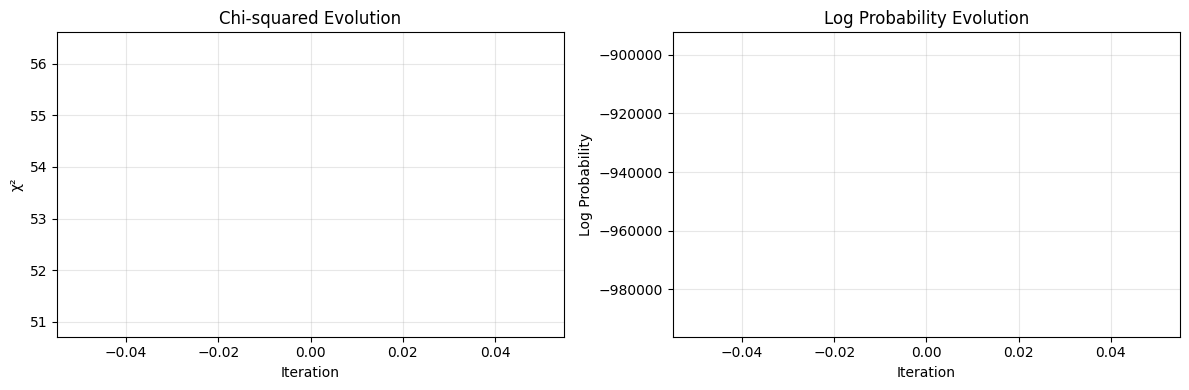

In [ ]:
# Plot optimization progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(chisq)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('χ²')
ax1.set_title('Chi-squared Evolution')
ax1.grid(True, alpha=0.3)

ax2.plot(lps)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Log Probability')
ax2.set_title('Log Probability Evolution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Create simulator for predictions
simulator = LensSimulator(phys_model, sim_config, bs=1)

# Convert best parameters to physical space and simulate
best_physical = prob_model.bij.forward(best.T.tolist())
simulated = simulator.simulate(best_physical)

# Calculate residuals
residual = obs - simulated
err_map = np.sqrt(background_rms**2 + obs / exp_time)
norm_residual = residual / err_map

print(f"✓ Simulation complete:")
print(f"  - Simulated image shape: {simulated.shape}")
print(f"  - RMS of normalized residuals: {np.std(norm_residual):.3f} σ")
print(f"  - Median normalized residual: {np.median(norm_residual):.3f} σ")

Simulated image shape: (200, 200)
RMS of normalized residuals: nan


/tmp/ipykernel_308241/234576533.py:10: RuntimeWarning: invalid value encountered in sqrt
  err_map = np.sqrt(background_rms**2 + obs / exp_time)


IndexError: Too many indices: 0-dimensional array indexed with 1 regular index.

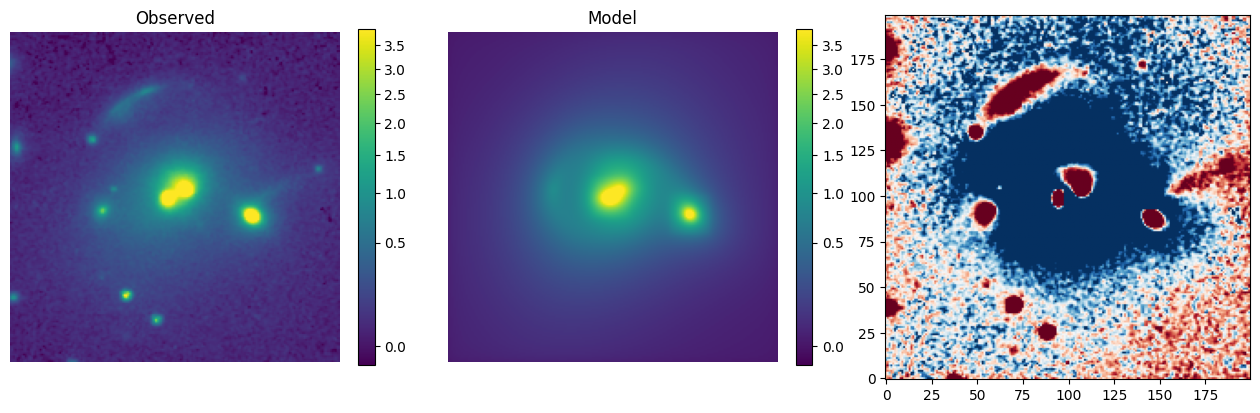

In [ ]:
# Create comparison plot - full image, no cutout
fig = plt.figure(figsize=(18, 6))

# Observed
ax1 = plt.subplot(131)
im1 = ax1.imshow(obs, norm=norm, cmap='viridis', origin='lower')
ax1.set_title('Observed Image', fontsize=14, fontweight='bold')
ax1.axis('off')
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046)
cbar1.set_label('Counts')

# Model
ax2 = plt.subplot(132)
im2 = ax2.imshow(simulated, norm=norm, cmap='viridis', origin='lower')
ax2.set_title('Model Prediction', fontsize=14, fontweight='bold')
ax2.axis('off')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046)
cbar2.set_label('Counts')

# Residuals
ax3 = plt.subplot(133)
im3 = ax3.imshow(norm_residual, cmap='RdBu_r', origin='lower', vmin=-4, vmax=4)
ax3.set_title(f'Normalized Residuals (χ²={chisq[-1]:.1f})', fontsize=14, fontweight='bold')
ax3.axis('off')
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046)
cbar3.set_label('σ')

plt.tight_layout()
plt.show()

## 7. (Optional) Posterior Sampling with HMC

In [ ]:
# Approximate posterior with SVI (optional)
# Uncomment to run

# num_svi_steps = 500
# schedule_fn = optax.polynomial_schedule(
#     init_value=1e-4,
#     end_value=1e-5,
#     power=1.0,
#     transition_steps=num_svi_steps,
# )
# optimizer = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)
#
# print("Starting SVI...")
# qz, loss_hist = model_seq.SVI(
#     best,
#     optimizer,
#     n_vi=100,
#     num_steps=num_svi_steps,
#     seed=0,
# )
# print("SVI complete!")
#
# plt.figure(figsize=(10, 4))
# plt.plot(loss_hist)
# plt.xlabel('Iteration')
# plt.ylabel('ELBO Loss')
# plt.title('SVI Optimization')
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# HMC sampling (optional)
# Uncomment to run - this is slow!

# n_chains = 16
# num_burnin = 200
# num_results = 500
#
# print(f"Starting HMC with {n_chains} chains...")
# samples = model_seq.HMC(
#     qz,
#     n_hmc=n_chains,
#     num_burnin_steps=num_burnin,
#     num_results=num_results,
# )
# print(f"HMC complete! Sample shape: {samples.shape}")

## 8. Save Results

In [ ]:
# Save best parameters and diagnostics
np.save('best_params.npy', best)
np.save('chisq_history.npy', chisq)
np.save('lp_history.npy', lps)
np.save('simulated_image.npy', simulated)
np.save('residuals.npy', norm_residual)

print("Results saved:")
print("  - best_params.npy")
print("  - chisq_history.npy")
print("  - lp_history.npy")
print("  - simulated_image.npy")
print("  - residuals.npy")